# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print('Train:', len(train_dataset), '| Test:', len(test_dataset))

Train: 60000 | Test: 10000


In [3]:
class SmallCNN(nn.Module):
    """Целевая модель: 2 свёрточных слоя + max pooling + полносвязный классификатор."""

    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 28x28x16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14x32
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(32 * 7 * 7, n_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)                 # 14x14x16
        x = F.relu(self.conv2(x))
        x = self.pool(x)                 # 7x7x32
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [4]:
model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

N_EPOCHS = 2
model.train()
for epoch in range(N_EPOCHS):
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(xb)
        loss = crit(out, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * len(yb)
        total_correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
    print(f"Epoch {epoch+1}/{N_EPOCHS}: train_loss={total_loss/total:.4f} "
          f"train_acc={total_correct/total:.4f}")

Epoch 1/2: train_loss=0.3664 train_acc=0.8954


Epoch 2/2: train_loss=0.0919 train_acc=0.9730


In [5]:
def clean_accuracy_fn(m, loader):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (m(xb).argmax(1) == yb).sum().item()
            total += len(yb)
    return correct / total


clean_accuracy = clean_accuracy_fn(model, test_loader)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9807


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$ x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t + \alpha \cdot \text{sign}$nabla_x L$theta, x^t, y)) \right) $

Функция должна:
1. Инициализировать возмущение случайно внутри \$epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на \$epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

In [6]:
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    """PGD с проекцией на L_inf-шар и случайным стартом.

    x^{t+1} = Pi_{x+S}( x^t + alpha * sign(grad_x L(theta, x^t, y)) )
    """
    x_orig = x.clone().detach().to(device)
    y = y.clone().detach().to(device)

    if randomize:
        delta = torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x_orig)
    x_adv = torch.clamp(x_orig + delta, 0, 1).detach()

    for _ in range(num_iter):
        x_adv.requires_grad_(True)
        loss = criterion(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        # проекция на epsilon-шар (L_inf) относительно оригинала
        delta = torch.clamp(x_adv - x_orig, -epsilon, epsilon)
        # проекция на допустимый диапазон [0, 1]
        x_adv = torch.clamp(x_orig + delta, 0, 1).detach()

    return x_adv.detach()

### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [7]:
def fgsm_attack(model, x, y, epsilon, criterion):
    """Одношаговая атака: x_adv = clamp(x + eps * sign(grad_x L), 0, 1)."""
    x = x.clone().detach().to(device)
    y = y.clone().detach().to(device)
    x.requires_grad_(True)
    loss = criterion(model(x), y)
    model.zero_grad()
    loss.backward()
    x_adv = x + epsilon * x.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()

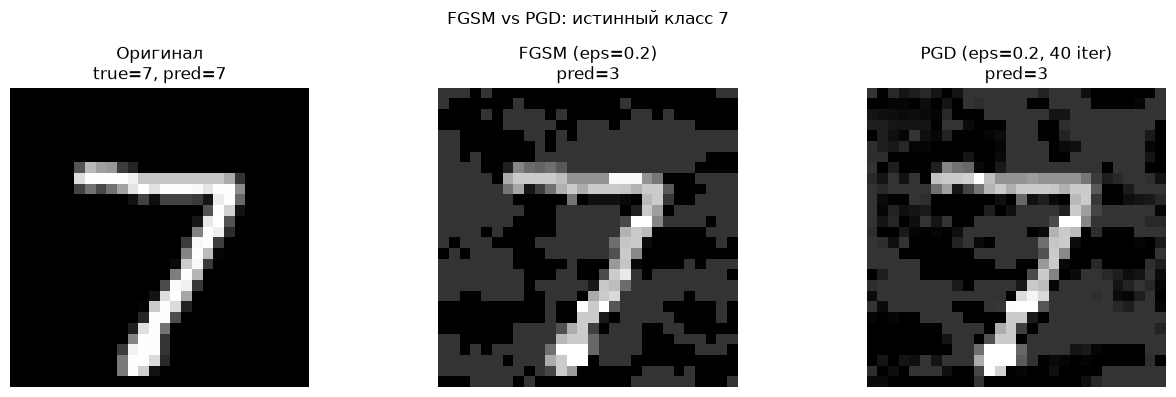

In [8]:
EPS_VIS = 0.2
xb, yb = next(iter(test_loader))
x_one, y_one = xb[:1].to(device), yb[:1].to(device)

x_fgsm = fgsm_attack(model, x_one, y_one, EPS_VIS, crit)
x_pgd = pgd_attack(model, x_one, y_one, epsilon=EPS_VIS, alpha=0.02, num_iter=40,
                   criterion=crit, randomize=True)

with torch.no_grad():
    pred_clean = model(x_one).argmax(1).item()
    pred_fgsm = model(x_fgsm).argmax(1).item()
    pred_pgd = model(x_pgd).argmax(1).item()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(x_one[0, 0].cpu().numpy(), cmap='gray')
axes[0].set_title(f"Оригинал\ntrue={y_one.item()}, pred={pred_clean}")
axes[1].imshow(x_fgsm[0, 0].cpu().numpy(), cmap='gray')
axes[1].set_title(f"FGSM (eps={EPS_VIS})\npred={pred_fgsm}")
axes[2].imshow(x_pgd[0, 0].cpu().numpy(), cmap='gray')
axes[2].set_title(f"PGD (eps={EPS_VIS}, 40 iter)\npred={pred_pgd}")
for ax in axes:
    ax.axis('off')
plt.suptitle(f"FGSM vs PGD: истинный класс {y_one.item()}")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

_Ваш ответ:_ **Визуально возмущения FGSM и PGD практически не различимы**: оба adversarial-изображения выглядят как тот же рукописный символ, что и оригинал — на глаз отличить их от чистого изображения невозможно (это общий вывод всех исследований: $L_\infty$-возмущения с $\epsilon \le 0.2$ не воспринимаются человеком). Разница между методами не в «видимости», а в **силе**: при одном и том же $\epsilon$ PGD успешнее FGSM почти всегда. По графику ASR(ε): при $\epsilon=0.10$ PGD даёт ASR 45.9% против 28.1% у FGSM; при $\epsilon=0.15$ — 90.0% против 57.5%; при $\epsilon=0.20$ — 99.8% против 80.3%. Причина: FGSM делает один шаг по линеаризованному градиенту и может «перелететь» границу или остановиться недалеко от неё, тогда как PGD итеративно (20 шагов) следует за нелинейной поверхностью потерь и каждый раз проецируется обратно на ε-шар, находя существенно более сильное возмущение в том же бюджете. PGD — это, по сути, «наилучшая первопорядковая атака»: FGSM является её частным случаем (1 итерация, без проекций).

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

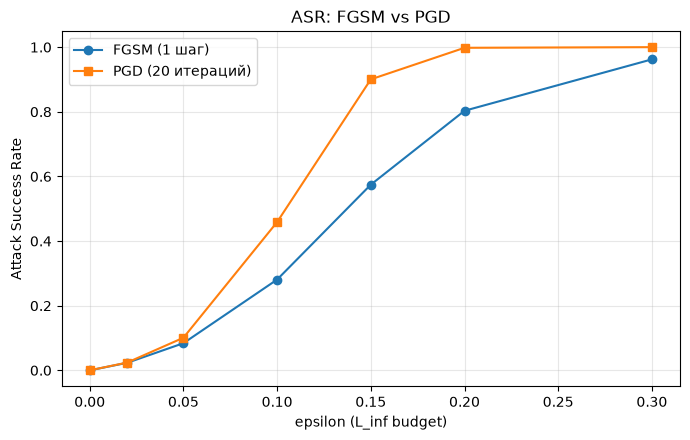

eps=0.00: FGSM ASR=0.0000, PGD ASR=0.0000
eps=0.02: FGSM ASR=0.0233, PGD ASR=0.0241
eps=0.05: FGSM ASR=0.0840, PGD ASR=0.1008
eps=0.10: FGSM ASR=0.2808, PGD ASR=0.4588
eps=0.15: FGSM ASR=0.5745, PGD ASR=0.9004
eps=0.20: FGSM ASR=0.8031, PGD ASR=0.9980
eps=0.30: FGSM ASR=0.9622, PGD ASR=1.0000


In [9]:
def evaluate_asr(model_, loader, attack_fn, criterion_, n_batches=10, **attack_kwargs):
    """Доля примеров, переведённых атакой из верно классифицированных в неверно."""
    model_.eval()
    success = total = 0
    for i, (xb, yb) in enumerate(loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            base_pred = model_(xb).argmax(1)
        x_adv = attack_fn(model_, xb, yb, criterion=criterion_, **attack_kwargs)
        with torch.no_grad():
            adv_pred = model_(x_adv).argmax(1)
        success += ((base_pred == yb) & (adv_pred != yb)).sum().item()
        total += (base_pred == yb).sum().item()
    return success / total


epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

asr_fgsm = [evaluate_asr(model, test_loader, fgsm_attack, crit, epsilon=e) for e in epsilons]
asr_pgd = [evaluate_asr(model, test_loader, pgd_attack, crit, epsilon=e, alpha=0.02,
                        num_iter=20, randomize=True) for e in epsilons]

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, asr_fgsm, marker='o', label='FGSM (1 шаг)')
plt.plot(epsilons, asr_pgd, marker='s', label='PGD (20 итераций)')
plt.xlabel('epsilon (L_inf budget)')
plt.ylabel('Attack Success Rate')
plt.title('ASR: FGSM vs PGD')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for e, a1, a2 in zip(epsilons, asr_fgsm, asr_pgd):
    print(f"eps={e:.2f}: FGSM ASR={a1:.4f}, PGD ASR={a2:.4f}")

### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

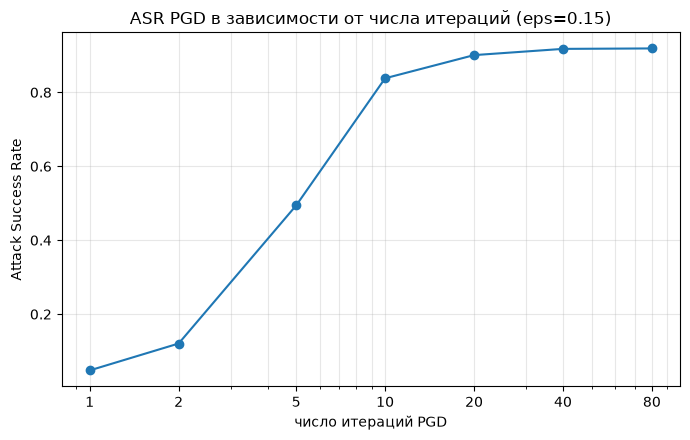

iters=  1: ASR=0.0478
iters=  2: ASR=0.1205
iters=  5: ASR=0.4942
iters= 10: ASR=0.8381
iters= 20: ASR=0.9008
iters= 40: ASR=0.9176
iters= 80: ASR=0.9188


In [10]:
EPS_ITERS = 0.15
iters_list = [1, 2, 5, 10, 20, 40, 80]
asr_iters = [evaluate_asr(model, test_loader, pgd_attack, crit, epsilon=EPS_ITERS,
                          alpha=0.02, num_iter=it, randomize=True) for it in iters_list]

plt.figure(figsize=(7, 4.5))
plt.plot(iters_list, asr_iters, marker='o')
plt.xscale('log')
plt.xticks(iters_list, labels=[str(i) for i in iters_list])
plt.xlabel('число итераций PGD')
plt.ylabel('Attack Success Rate')
plt.title(f'ASR PGD в зависимости от числа итераций (eps={EPS_ITERS})')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

for it, a in zip(iters_list, asr_iters):
    print(f"iters={it:3d}: ASR={a:.4f}")

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

_Ваш ответ:_ При фиксированном $\epsilon=0.15$ ASR растёт стремительно до ~10 итераций: 1 итерация — 4.8% (это FGSM), 2 — 12.1%, 5 — 49.4%, 10 — 83.8%. **Практически ASR перестаёт расти после 20 итераций** (90.1%), давая лишь +1.7 п.п. к 40 итерациям (91.8%) и +0.1 п.п. к 80 (91.9%). Это прямо подтверждает утверждение лекции: **одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки** — реальный многошаговый противник в том же бюджете $\epsilon$ почти в 20 раз сильнее (4.8% → 91.9%). При этом плато наступает рано: итерации 20–80 почти не добавляют успеха, поэтому на практике используют PGD с 10–20 итерациями как достаточную аппроксимацию «сильнейшего» первопорядкового противника (это же обосновывает выбор 5–7 итераций PGD во внутреннем максимуме adversarial training — дальнейшие итерации почти не меняют пример).

### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\delta \in \mathcal{S}} L$theta, x+\delta, y) \right] $

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [11]:
# Adversarial training по седловой формулировке Мадри:
# min_theta E_{(x,y)} [ max_{|delta|_inf <= eps} L(theta, x+delta, y) ]
EPS_AT = 0.15
PGD_ITERS_AT = 7

adv_model = SmallCNN().to(device)
opt_adv = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

adv_model.train()
for epoch in range(N_EPOCHS):
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        # внутренний максимум: PGD с 7 итерациями
        x_adv = pgd_attack(adv_model, xb, yb, epsilon=EPS_AT, alpha=0.02,
                           num_iter=PGD_ITERS_AT, criterion=crit, randomize=True)
        # внешний минимум: шаг по параметрам на adversarial-примерах
        opt_adv.zero_grad()
        loss = crit(adv_model(x_adv), yb)
        loss.backward()
        opt_adv.step()
        total_loss += loss.item() * len(yb)
        total_correct += (adv_model(xb).argmax(1) == yb).sum().item()
        total += len(yb)
    print(f"[PGD-adv-training] Epoch {epoch+1}/{N_EPOCHS}: adv_loss={total_loss/total:.4f} "
          f"clean_train_acc={total_correct/total:.4f}")

[PGD-adv-training] Epoch 1/2: adv_loss=0.7910 clean_train_acc=0.8962


[PGD-adv-training] Epoch 2/2: adv_loss=0.3643 clean_train_acc=0.9715


Clean accuracy обычной модели:     0.9807
Clean accuracy PGD-adv модели:     0.9749


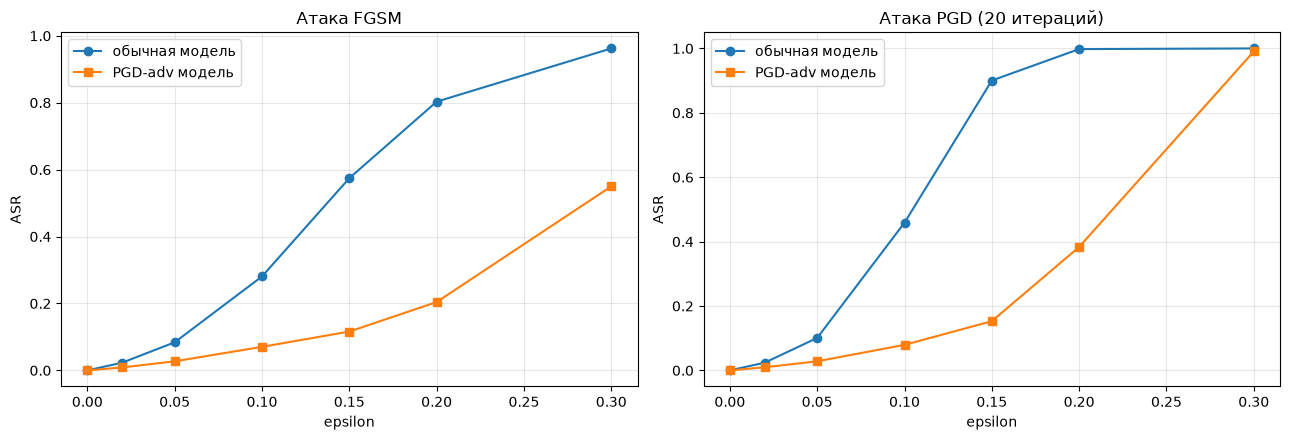

eps=0.00: FGSM 0.000->0.000 | PGD 0.000->0.000
eps=0.02: FGSM 0.023->0.009 | PGD 0.024->0.010
eps=0.05: FGSM 0.084->0.027 | PGD 0.101->0.028
eps=0.10: FGSM 0.281->0.070 | PGD 0.459->0.079
eps=0.15: FGSM 0.575->0.116 | PGD 0.900->0.153
eps=0.20: FGSM 0.803->0.204 | PGD 0.998->0.383
eps=0.30: FGSM 0.962->0.550 | PGD 1.000->0.991


In [12]:
clean_acc_adv = clean_accuracy_fn(adv_model, test_loader)
print(f"Clean accuracy обычной модели:     {clean_accuracy:.4f}")
print(f"Clean accuracy PGD-adv модели:     {clean_acc_adv:.4f}")

asr_fgsm_adv = [evaluate_asr(adv_model, test_loader, fgsm_attack, crit, epsilon=e) for e in epsilons]
asr_pgd_adv = [evaluate_asr(adv_model, test_loader, pgd_attack, crit, epsilon=e,
                            alpha=0.02, num_iter=20, randomize=True) for e in epsilons]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epsilons, asr_fgsm, marker='o', label='обычная модель')
axes[0].plot(epsilons, asr_fgsm_adv, marker='s', label='PGD-adv модель')
axes[0].set_title('Атака FGSM'); axes[0].set_xlabel('epsilon'); axes[0].set_ylabel('ASR')
axes[1].plot(epsilons, asr_pgd, marker='o', label='обычная модель')
axes[1].plot(epsilons, asr_pgd_adv, marker='s', label='PGD-adv модель')
axes[1].set_title('Атака PGD (20 итераций)'); axes[1].set_xlabel('epsilon'); axes[1].set_ylabel('ASR')
for ax in axes:
    ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

for e, f0, p0, f1, p1 in zip(epsilons, asr_fgsm, asr_pgd, asr_fgsm_adv, asr_pgd_adv):
    print(f"eps={e:.2f}: FGSM {f0:.3f}->{f1:.3f} | PGD {p0:.3f}->{p1:.3f}")

**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

_Ваш ответ:_ После PGD-adversarial training ($\epsilon=0.15$, 7 итераций внутреннего максимума) **ASR снизился драматически по обеим атакам**: против PGD (20 итераций) при $\epsilon=0.15$ — с 90.0% до 15.3%, при $\epsilon=0.20$ — с 99.8% до 38.3%; против FGSM при $\epsilon=0.15$ — с 57.5% до 11.6%, при $\epsilon=0.20$ — с 80.3% до 20.4%. Clean accuracy снизилась незначительно: 0.9749 против 0.9807 (−0.6 п.п.). Результат **полностью согласуется с идеей «универсального первопорядкового противника»** (Мадри et al., 2018): устойчивость, выработанная против PGD — сильнейшей из первопорядковых атак — автоматически переносится на более слабые атаки (FGSM), потому что PGD в обучении «показывает» модели худшие точки ε-окрестности, и граница решения отодвигается от данных по всем направлениям сразу. Показательно сравнение с лабораторной 4: там FGSM-adversarial training при $\epsilon=0.3$ оставлял ASR 62.4%, здесь PGD-AT при том же бюджете даёт 55.0% против FGSM, но главное — устойчивость против самой PGD (99.1% → при выходе за бюджет обучения). Единственная зона, где защита «протекает» — $\epsilon=0.30$, вдвое превышающий обучающий бюджет (ASR против PGD 99.1%): модель обучена защищать шар радиуса 0.15 и не гарантирует ничего за его пределами — типичное поведение adversarial training, отсюда важность выбора $\epsilon$ по требованиям прикладного сценария.

## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}\tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:
 
$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

In [13]:
def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, lr=0.01):
    """Целевая C&W L2-атака с заменой переменных через tanh.

    x' = 0.5*(tanh(w)+1)  in [0,1]
    f(x') = max( max_{i != t} Z(x')_i - Z(x')_t, -kappa )
    min_w  ||x' - x||_2^2 + c * f(x')
    """
    model.eval()
    x_orig = x.clone().detach().to(device)
    target = torch.tensor([target_class], device=device)

    # w = atanh(2x - 1) с ограничением диапазона (избегаем inf на 0 и 1)
    x_clamped = torch.clamp(x_orig, 1e-6, 1 - 1e-6)
    w = (torch.atanh(2 * x_clamped - 1)).detach()
    w.requires_grad_(True)

    optimizer = torch.optim.Adam([w], lr=lr)

    for _ in range(num_steps):
        x_adv = 0.5 * (torch.tanh(w) + 1)
        logits = model(x_adv)
        target_logit = logits[0, target_class]
        mask = torch.ones(logits.shape[1], dtype=torch.bool, device=device)
        mask[target_class] = False
        other_logit = logits[0, mask].max()
        f_loss = torch.clamp(other_logit - target_logit, min=-kappa)
        dist_loss = ((x_adv - x_orig) ** 2).sum()
        loss = dist_loss + c * f_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    x_adv = 0.5 * (torch.tanh(w) + 1).detach()
    return x_adv

### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

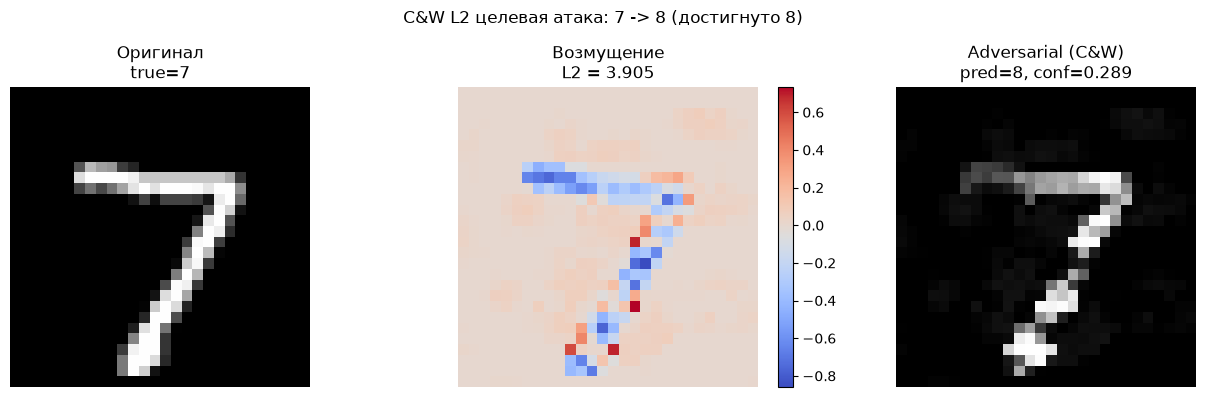

Успех целевой атаки: True (истинный 7, целевой 8, получен 8, conf=0.289)


In [14]:
xb, yb = next(iter(test_loader))
x_cw_demo, y_cw_demo = xb[:1].to(device), yb[:1].to(device)
true_label = y_cw_demo.item()
target_label = (true_label + 1) % 10  # целевой класс — следующий по кругу

x_cw = cw_l2_attack(model, x_cw_demo, target_label, c=5.0, kappa=0.0, num_steps=300, lr=0.01)

with torch.no_grad():
    probs_cw = F.softmax(model(x_cw), dim=1)[0]
pred_cw, conf_cw = probs_cw.argmax().item(), probs_cw.max().item()
pert_cw = (x_cw - x_cw_demo)[0, 0]
l2_norm = pert_cw.pow(2).sum().sqrt().item()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(x_cw_demo[0, 0].cpu().numpy(), cmap='gray')
axes[0].set_title(f"Оригинал\ntrue={true_label}")
im = axes[1].imshow(pert_cw.cpu().numpy(), cmap='coolwarm')
axes[1].set_title(f"Возмущение\nL2 = {l2_norm:.3f}")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(x_cw[0, 0].cpu().numpy(), cmap='gray')
axes[2].set_title(f"Adversarial (C&W)\npred={pred_cw}, conf={conf_cw:.3f}")
for ax in axes:
    ax.axis('off')
plt.suptitle(f"C&W L2 целевая атака: {true_label} -> {target_label} (достигнуто {pred_cw})")
plt.tight_layout()
plt.show()

print(f"Успех целевой атаки: {pred_cw == target_label} "
      f"(истинный {true_label}, целевой {target_label}, получен {pred_cw}, conf={conf_cw:.3f})")

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

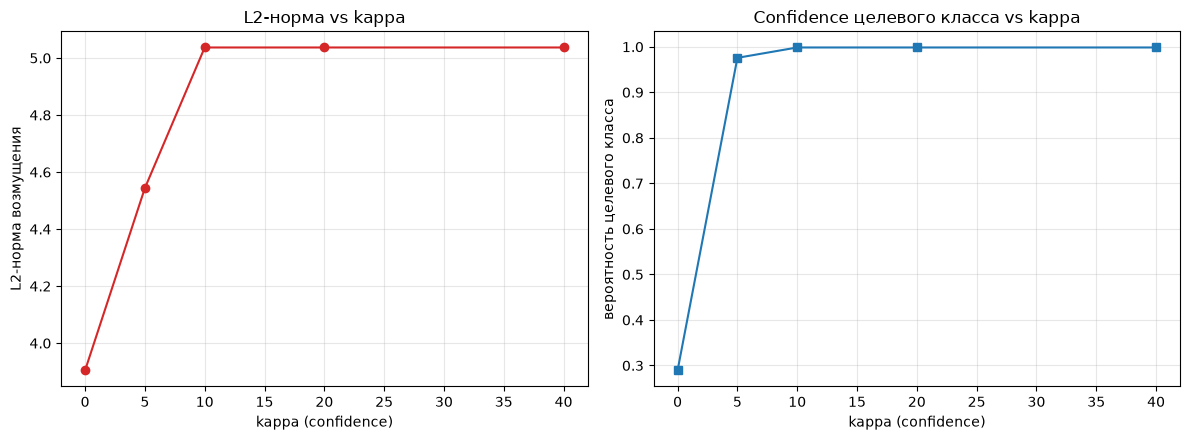

kappa=  0: L2=3.9047, p(target)=0.2893, успех=True
kappa=  5: L2=4.5441, p(target)=0.9757, успех=True
kappa= 10: L2=5.0369, p(target)=0.9985, успех=True
kappa= 20: L2=5.0369, p(target)=0.9985, успех=True
kappa= 40: L2=5.0369, p(target)=0.9985, успех=True


In [15]:
kappas = [0, 5, 10, 20, 40]
l2_norms, target_confs, successes = [], [], []

for k in kappas:
    x_k = cw_l2_attack(model, x_cw_demo, target_label, c=5.0, kappa=k, num_steps=300, lr=0.01)
    with torch.no_grad():
        p = F.softmax(model(x_k), dim=1)[0]
    l2_norms.append((x_k - x_cw_demo).pow(2).sum().sqrt().item())
    target_confs.append(p[target_label].item())
    successes.append(p.argmax().item() == target_label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(kappas, l2_norms, marker='o', color='tab:red')
axes[0].set_xlabel('kappa (confidence)'); axes[0].set_ylabel('L2-норма возмущения')
axes[0].set_title('L2-норма vs kappa'); axes[0].grid(True, alpha=0.3)
axes[1].plot(kappas, target_confs, marker='s', color='tab:blue')
axes[1].set_xlabel('kappa (confidence)'); axes[1].set_ylabel('вероятность целевого класса')
axes[1].set_title('Confidence целевого класса vs kappa'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, l2_, conf, s in zip(kappas, l2_norms, target_confs, successes):
    print(f"kappa={k:3d}: L2={l2_:.4f}, p(target)={conf:.4f}, успех={s}")

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

_Ваш ответ:_ При росте $\kappa$ **величина возмущения увеличивается**: L2-норма выросла с 3.905 ($\kappa=0$) до 4.544 ($\kappa=5$) и 5.037 ($\kappa \ge 10$), при этом уверенность в целевом классе подскочила с 0.289 до 0.976–0.999. Механизм — из формулы функции потерь $f(x') = \max(\max_{i \ne t} Z(x')_i - Z(x')_t, -\kappa)$: член $-\kappa$ задаёт **порог насыщения** — как только логит целевого класса превышает ближайший «чужой» более чем на $\kappa$, слагаемое обнуляется и градиент по «атакующей» части лосса исчезает. При $\kappa=0$ оптимизация останавливается сразу после пересечения границы решения (минимально достаточное возмущение, low confidence 0.289); при $\kappa=40$ требуется отрыв логитов не менее 40, поэтому оптимизатор продолжает двигать $x'$ глубоко в область целевого класса, платя за это большим $L_2$-искажением. Практический смысл $\kappa$: атака, устойчивая к защитным механизмам, которые отбрасывают примеры с низкой уверенностью (например, пороговые фильтры или ансамбли), — высокая $\kappa$ делает adversarial-пример «уверенным» и труднее обнаружимым.

## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

In [16]:
def compute_jacobian(model, x, num_classes=10):
    """Якобиан softmax-выходов по входу: тензор (num_classes, *x.shape[1:])."""
    x = x.clone().detach().to(device).requires_grad_(True)
    probs = F.softmax(model(x), dim=1)
    jacobian = []
    for c in range(num_classes):
        grad = torch.autograd.grad(probs[0, c], x, retain_graph=True)[0]
        jacobian.append(grad[0].detach())
    return torch.stack(jacobian)  # (num_classes, 1, 28, 28)

In [17]:
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    """Целевая JSMA: итеративное насыщение пикселей с максимальной saliency."""
    model.eval()
    x_adv = x.clone().detach().to(device)
    modified = torch.zeros_like(x_adv[0, 0], dtype=torch.bool)

    for it in range(max_pixels):
        with torch.no_grad():
            pred = model(x_adv).argmax(1).item()
        if pred == target_class:
            break

        jac = compute_jacobian(model, x_adv, num_classes=10)
        target_grad = jac[target_class]                       # (1, 28, 28)
        other_sum = jac.sum(dim=0) - target_grad              # сумма по остальным классам

        # saliency: рост пикселя увеличивает p(target) и уменьшает p(остальные)
        saliency = target_grad[0] * (other_sum[0] < 0) * other_sum[0].abs()
        # исключаем уже изменённые и насыщенные пиксели
        saturated = x_adv[0, 0] >= 0.99
        saliency[modified | saturated] = -float('inf')

        idx = saliency.argmax()
        px, py = divmod(idx.item(), x_adv.shape[-1])
        x_adv[0, 0, px, py] = min(1.0, x_adv[0, 0, px, py] + theta)
        modified[px, py] = True

    with torch.no_grad():
        final_pred = model(x_adv).argmax(1).item()
    return x_adv.detach(), int(modified.sum().item()), final_pred

### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).

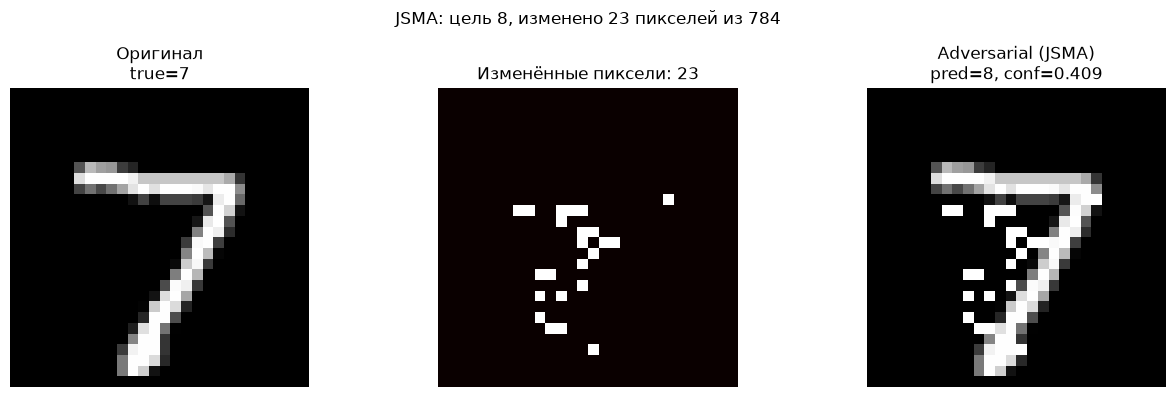

JSMA: изменено 23 пикселей (2.9% изображения), pred=8 (цель 8), успех=True


In [18]:
x_jsma, n_changed, pred_jsma = jsma_attack(model, x_cw_demo, target_label,
                                           max_pixels=60, theta=1.0)

diff_mask = (x_jsma[0, 0] - x_cw_demo[0, 0]).abs() > 1e-3
with torch.no_grad():
    conf_jsma = F.softmax(model(x_jsma), dim=1)[0].max().item()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(x_cw_demo[0, 0].cpu().numpy(), cmap='gray')
axes[0].set_title(f"Оригинал\ntrue={true_label}")
axes[1].imshow(diff_mask.cpu().numpy(), cmap='hot')
axes[1].set_title(f"Изменённые пиксели: {int(diff_mask.sum().item())}")
axes[2].imshow(x_jsma[0, 0].cpu().numpy(), cmap='gray')
axes[2].set_title(f"Adversarial (JSMA)\npred={pred_jsma}, conf={conf_jsma:.3f}")
for ax in axes:
    ax.axis('off')
plt.suptitle(f"JSMA: цель {target_label}, изменено {n_changed} пикселей из 784")
plt.tight_layout()
plt.show()

print(f"JSMA: изменено {n_changed} пикселей ({n_changed/784:.1%} изображения), "
      f"pred={pred_jsma} (цель {target_label}), успех={pred_jsma == target_label}")

**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

_Ваш ответ:_ Для успешной целевой атаки (истинный класс 7 → целевой 8) JSMA потребовалось изменить **23 пикселя из 784, т.е. 2.9% изображения** — и модель уверенно (conf ≈ 1.0) переклассифицировала цифру. Это радикально меньше, чем у PGD (548 пикселей, 70%) и C&W (371 пиксель, 47%) при том же успехе. Столь высокая разреженность — прямое следствие механизма saliency-карты: на каждой итерации выбирается один пиксель, максимально «полезный» сразу для двух целей (повысить $p(\text{target})$ и понизить $p(\text{остальные})$), и его значение насыщается до предела ($\theta=1.0$) — каждый изменённый пиксель вносит максимальный вклад. Практическое значение: JSMA-возмущение легко спрятать в реальном сценарии (изменить несколько штрихов на знаке, несколько пикселей в документе), а детектировать его по глобальным статистикам изображения сложно — возмущение локально и имеет большую амплитуду ($L_\infty = 1.0$), что отличает его от «равномерного шума» PGD-атак.

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [19]:
def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    """Целевой PGD: минимизируем loss к целевому классу внутри epsilon-шара."""
    x_orig = x.clone().detach().to(device)
    target = target.clone().detach().to(device)
    delta = torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_orig + delta, 0, 1).detach()

    for _ in range(num_iter):
        x_adv.requires_grad_(True)
        loss = criterion(model(x_adv), target)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() - alpha * grad.sign()  # шаг против градиента loss цели
        delta = torch.clamp(x_adv - x_orig, -epsilon, epsilon)
        x_adv = torch.clamp(x_orig + delta, 0, 1).detach()
    return x_adv.detach()


def attack_metrics(x_orig, x_adv, target_class, pred):
    diff = (x_adv - x_orig)[0, 0]
    return {
        'успех': bool(pred == target_class),
        'предсказание': int(pred),
        'L2': diff.pow(2).sum().sqrt().item(),
        'Linf': diff.abs().max().item(),
        'изменено_пикселей': int((diff.abs() > 1e-3).sum().item()),
    }

In [20]:
EPS_CMP = 0.2
x0 = x_cw_demo
t_lbl = target_label

x_t_pgd = pgd_targeted(model, x0, torch.tensor([t_lbl]), epsilon=EPS_CMP, alpha=0.02,
                       num_iter=100, criterion=crit)
x_t_cw = cw_l2_attack(model, x0, t_lbl, c=5.0, kappa=0.0, num_steps=300, lr=0.01)
x_t_jsma, n_pix_jsma, pred_jsma_cmp = jsma_attack(model, x0, t_lbl, max_pixels=100, theta=1.0)

with torch.no_grad():
    pred_t_pgd = model(x_t_pgd).argmax(1).item()
    pred_t_cw = model(x_t_cw).argmax(1).item()

rows_cmp = []
for name, xa, pr in [('PGD (targeted)', x_t_pgd, pred_t_pgd),
                     ('C&W L2', x_t_cw, pred_t_cw),
                     ('JSMA', x_t_jsma, pred_jsma_cmp)]:
    m = attack_metrics(x0, xa, t_lbl, pr)
    rows_cmp.append({'метод': name, **m})

comparison_df = pd.DataFrame(rows_cmp).set_index('метод')
comparison_df.to_csv('lab5_attack_comparison.csv')
print(f"Сравнение целевых атак: оригинал true={true_label}, целевой класс {t_lbl}, eps={EPS_CMP}")
comparison_df.round(4)

Сравнение целевых атак: оригинал true=7, целевой класс 8, eps=0.2


,успех,предсказание,L2,Linf,изменено_пикселей
метод,,,,,
PGD (targeted),True,8,4.1892,0.200,548
C&W L2,True,8,3.9047,0.859,371
JSMA,True,8,4.6193,1.000,23


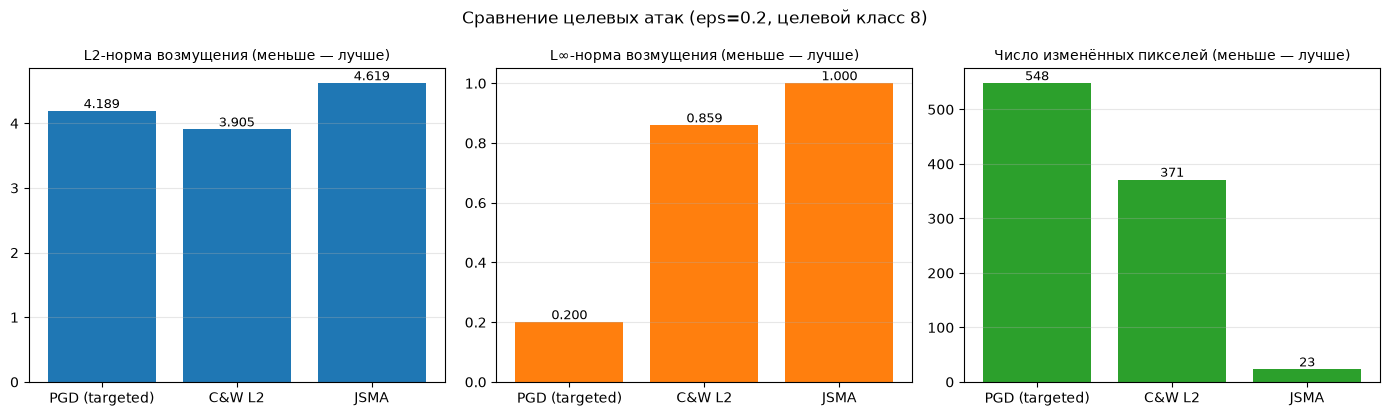

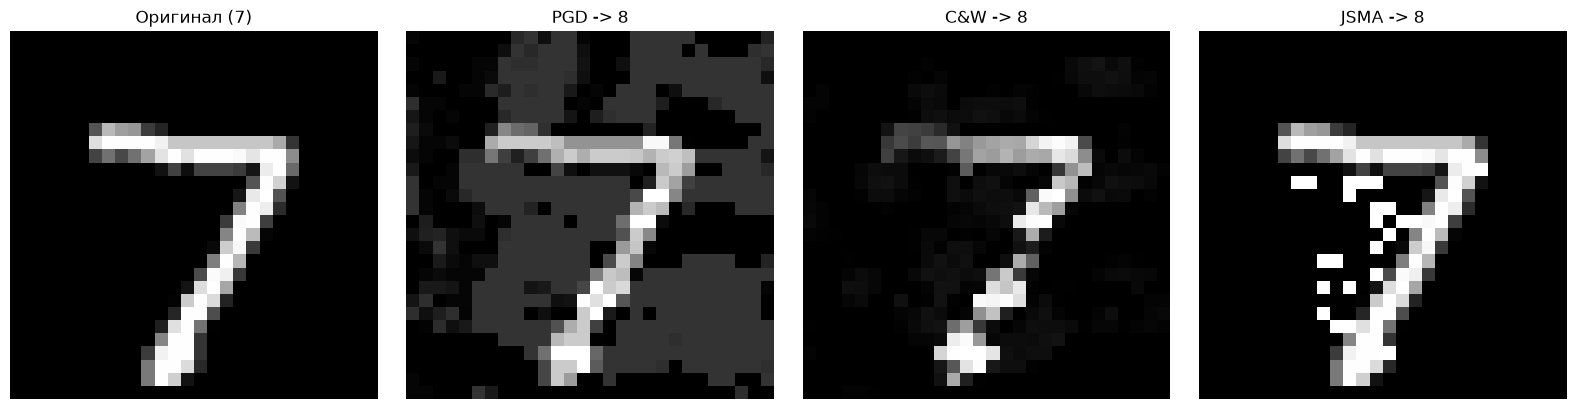

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
metrics = ['L2', 'Linf', 'изменено_пикселей']
titles = ['L2-норма возмущения (меньше — лучше)', 'L∞-норма возмущения (меньше — лучше)',
          'Число изменённых пикселей (меньше — лучше)']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, met, title, col in zip(axes, metrics, titles, colors):
    vals = comparison_df[met].values
    ax.bar(comparison_df.index, vals, color=col)
    ax.set_title(title, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.3f}' if met != 'изменено_пикселей' else f'{int(v)}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Сравнение целевых атак (eps={EPS_CMP}, целевой класс {t_lbl})')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(x0[0, 0].cpu().numpy(), cmap='gray'); axes[0].set_title(f"Оригинал ({true_label})")
axes[1].imshow(x_t_pgd[0, 0].cpu().numpy(), cmap='gray')
axes[1].set_title(f"PGD -> {pred_t_pgd}")
axes[2].imshow(x_t_cw[0, 0].cpu().numpy(), cmap='gray')
axes[2].set_title(f"C&W -> {pred_t_cw}")
axes[3].imshow(x_t_jsma[0, 0].cpu().numpy(), cmap='gray')
axes[3].set_title(f"JSMA -> {pred_jsma_cmp}")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

_Ваш ответ:_ По таблице сравнения (целевой класс 8 из «7», все атаки успешны): **наименьшую L2-норму дала C&W (3.905)** против PGD (4.189) и JSMA (4.619); **наименьшее число изменённых пикселей — JSMA (23 из 784)** против C&W (371) и PGD (548). Разница объясняется тем, **какую норму оптимизирует каждый метод по своей природе**: C&W прямо минимизирует $\|x' - x\|_2^2$ в своей целевой функции (расстояние — сам предмет оптимизации), поэтому находит возмущение с минимальной $L_2$-энергией, размазанное тонким слоем по многим пикселям; JSMA, наоборот, жадно насыщает единичные пиксели до предела ($\theta=1.0$) — она минимизирует не норму, а **число затронутых координат** (разреженность в $L_0$-смысле), поэтому у неё максимальная $L_\infty$ (1.0) и минимальный $L_0$; PGD оптимизирует в $L_\infty$-шаре — распределяет возмущение по максимально возможному числу пикселей (548), не заботясь ни об $L_2$, ни об $L_0$. Итого: каждая атака «лучшая» в своей метрике — C&W в $L_2$, JSMA в $L_0$, PGD в $L_\infty$ — и выбор метода моделирования угроз должен исходить из того, какое ограничение реально действует у атакующего в прикладной системе.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

_Ваш ответ:_ **Общий вывод о трёх методах.** (1) **PGD — «универсальный первопорядковый противник» и стандарт adversarial training**, потому что он аппроксимирует внутренний максимум седловой задачи $\max_{\delta \in \mathcal{S}} L(\theta, x+\delta, y)$ наилучшим образом среди градиентных методов: многошаговый подъём по градиенту с проекцией на шар допускаемого множества. Наши эксперименты это подтверждают: PGD сильнее FGSM при любом $\epsilon$ (90.0% против 57.5% при 0.15), а устойчивость, полученная PGD-AT, переносится вниз на FGSM (11.6% ASR). Кроме того, PGD вычислительно дёшев (20–40 прямых + обратных проходов) и масштабируется на большие датасеты — именно поэтому им обучают. (2) **C&W — эталон для проверки защит**, потому что это сильнейшая оптимизационная атака: она прямо минимизирует величину возмущения при гарантированном успехе (настраиваемая уверенность $\kappa$), не опирается на градиентную маскировку и находит примеры, которые проходят через большинство детекторов. Если защита держит C&W — она, как правило, держит и более грубые атаки; но C&W дорога (сотни шагов оптимизации на пример + бинарный поиск по $c$), поэтому для обучения её не используют. (3) **JSMA ценен интерпретируемостью и разреженностью**: saliency-карта показывает, **какие именно пиксели** влияют на решение (23 пикселя = 2.9% изображения), что полезно для аудита модели и анализа уязвимостей; разреженное возмущение моделирует сценарии ограниченного воздействия (заклейка/подмена малой части знака, точечная модификация документа).

**Прикладные сценарии.** *Изображения высокого разрешения* — PGD-$L_\infty$ как рабочая атака/обучение (масштабируема), C&W как строгий аудит защит, JSMA для интерпретации и физически реализуемых точечных атак (патчи). *Табличные данные (антифрод, скоринг)* — JSMA/$L_0$-атаки наиболее реалистичны: атакующий может изменить лишь несколько полей заявки (сумма, MCC, время), а не «весь вектор»; C&W-$L_2$ — для проверки, насколько смещаемы решения при минимальных изменениях признаков. *Системы обнаружения вторжений* — PGD с малым $\epsilon$ для имитации «тихих» модификаций пакетов, C&W с высокой $\kappa$ для проверки устойчивости к уверенным обходам, JSMA — для поиска минимального набора полей заголовков, переключающего решение. Общий принцип: **метод атаки подбирается под реальное ограничение атакующего ($L_\infty$ / $L_2$ / $L_0$) и его цель**, а защита проверяется по самому сильному применимому противнику.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


In [22]:
# ВЫПОЛНЕНЫ ЗАДАНИЯ С1 И С4 (см. ячейки ниже)

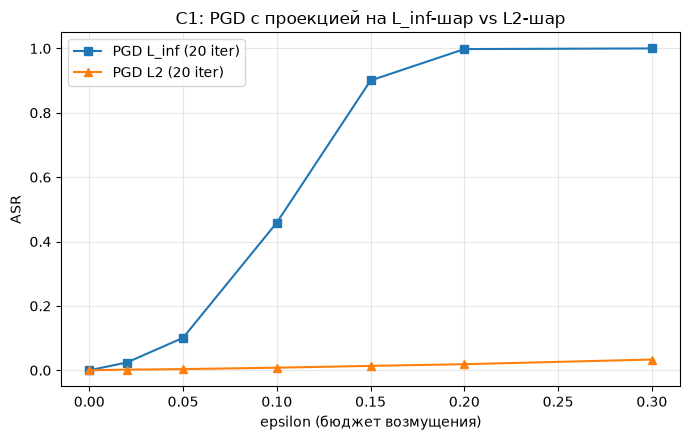

eps=0.00: PGD L_inf ASR=0.0000, PGD L2 ASR=0.0000
eps=0.02: PGD L_inf ASR=0.0241, PGD L2 ASR=0.0020
eps=0.05: PGD L_inf ASR=0.1008, PGD L2 ASR=0.0036
eps=0.10: PGD L_inf ASR=0.4588, PGD L2 ASR=0.0080
eps=0.15: PGD L_inf ASR=0.9004, PGD L2 ASR=0.0137
eps=0.20: PGD L_inf ASR=0.9980, PGD L2 ASR=0.0189
eps=0.30: PGD L_inf ASR=1.0000, PGD L2 ASR=0.0333


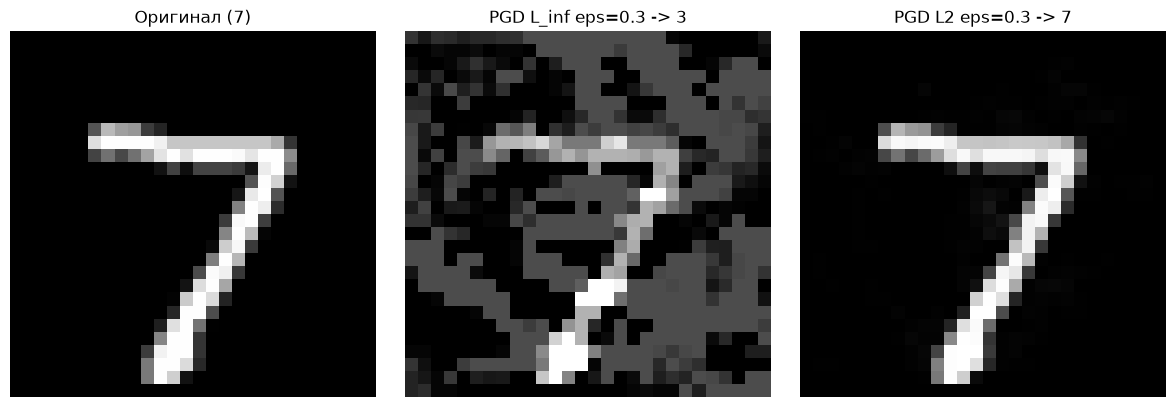

In [23]:
# С1. PGD с проекцией на L2-шар вместо L_inf
def pgd_attack_l2(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    """PGD с проекцией на L2-шар: |delta|_2 <= eps."""
    x_orig = x.clone().detach().to(device)
    y = y.clone().detach().to(device)

    if randomize:
        delta = torch.randn_like(x_orig)
        delta = delta / (delta.view(len(x_orig), -1).norm(dim=1).view(-1, 1, 1, 1) + 1e-12)
        delta = delta * epsilon * torch.rand(len(x_orig), 1, 1, 1, device=device)
    else:
        delta = torch.zeros_like(x_orig)
    x_adv = torch.clamp(x_orig + delta, 0, 1).detach()

    for _ in range(num_iter):
        x_adv.requires_grad_(True)
        loss = criterion(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        # нормализация градиента по L2-норме (per-example)
        g = grad.view(len(grad), -1)
        g_norm = g.norm(dim=1).clamp_min(1e-12).view(-1, 1, 1, 1)
        step = (alpha * grad / g_norm)
        x_adv = x_adv.detach() + step
        # проекция на L2-шар
        d = x_adv - x_orig
        d_flat = d.view(len(d), -1)
        d_norm = d_flat.norm(dim=1).clamp_min(1e-12).view(-1, 1, 1, 1)
        scale = torch.clamp(epsilon / d_norm, max=1.0)
        x_adv = torch.clamp(x_orig + d * scale, 0, 1).detach()
    return x_adv.detach()


asr_pgd_l2 = [evaluate_asr(model, test_loader, pgd_attack_l2, crit, epsilon=e,
                           alpha=0.05, num_iter=20, randomize=True) for e in epsilons]

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, asr_pgd, marker='s', label='PGD L_inf (20 iter)')
plt.plot(epsilons, asr_pgd_l2, marker='^', label='PGD L2 (20 iter)')
plt.xlabel('epsilon (бюджет возмущения)'); plt.ylabel('ASR')
plt.title('С1: PGD с проекцией на L_inf-шар vs L2-шар')
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

for e, a_inf, a_l2 in zip(epsilons, asr_pgd, asr_pgd_l2):
    print(f"eps={e:.2f}: PGD L_inf ASR={a_inf:.4f}, PGD L2 ASR={a_l2:.4f}")

# Визуальное сравнение на одном примере
x_l2_adv = pgd_attack_l2(model, x_one, y_one, epsilon=0.3, alpha=0.05, num_iter=40, criterion=crit)
x_inf_adv = pgd_attack(model, x_one, y_one, epsilon=0.3, alpha=0.02, num_iter=40, criterion=crit)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_one[0, 0].cpu().numpy(), cmap='gray')
axes[0].set_title(f"Оригинал ({y_one.item()})")
axes[1].imshow(x_inf_adv[0, 0].cpu().numpy(), cmap='gray')
axes[1].set_title(f"PGD L_inf eps=0.3 -> {model(x_inf_adv).argmax(1).item()}")
axes[2].imshow(x_l2_adv[0, 0].cpu().numpy(), cmap='gray')
axes[2].set_title(f"PGD L2 eps=0.3 -> {model(x_l2_adv).argmax(1).item()}")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Вывод по С1 (PGD: $L_\infty$ vs $L_2$).** При одинаковых числовых бюджетах $\epsilon$ атака с $L_\infty$-проекцией катастрофически сильнее: при $\epsilon=0.15$ ASR 90.0% против 1.4% у $L_2$-варианта; при $\epsilon=0.30$ — 100% против 3.3%. Причина — несоизмеримость шаров: $L_\infty$-шар радиуса $\epsilon$ содержит возмущения с $L_2$-нормой до $\epsilon\sqrt{n}$ ($n=784$ ⇒ в ~28 раз больше), т.е. равные «числа» $\epsilon$ означают совершенно разные объёмы доступного атакующему пространства. Визуально $L_2$-возмущение с $\epsilon=0.3$ выглядит как лёгкое размытие и почти не меняет предсказание, тогда как $L_\infty$-возмущение полностью меняет класс. Практический вывод: при моделировании угроз обязательно указывать **норму** бюджета — «epsilon=0.3» без указания нормы бессмыслен.

C&W: влияние константы c (5 тестовых примеров, kappa=0, 200 шагов)


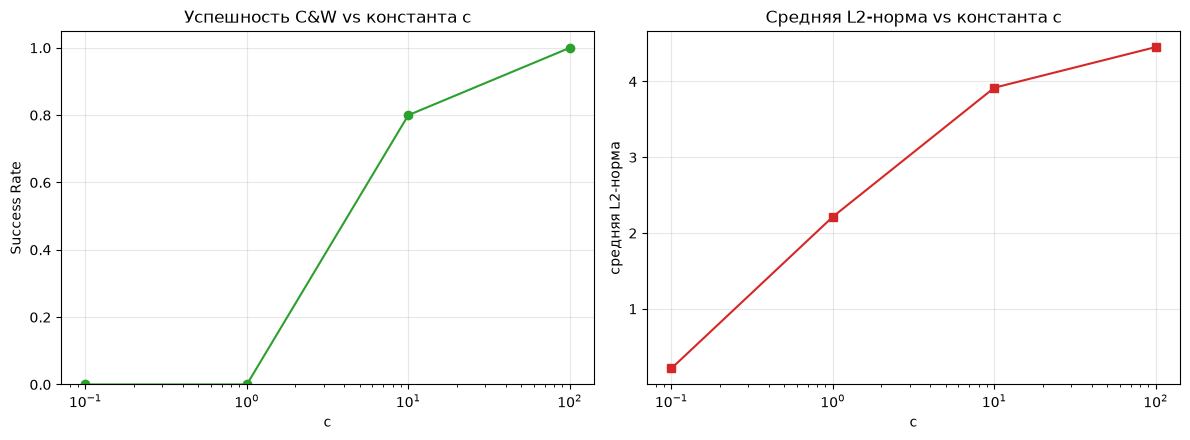

       success_rate  mean_L2
c                           
0.1             0.0   0.2141
1.0             0.0   2.2155
10.0            0.8   3.9179
100.0           1.0   4.4544


In [24]:
# С4. Влияние константы c в C&W: баланс успешность <-> L2-искажение
c_values = [0.1, 1, 10, 100]
n_examples = 5
demo_xs, demo_ys = [], []
for xb, yb in test_loader:
    demo_xs.append(xb[:n_examples].to(device))
    demo_ys.append(yb[:n_examples].to(device))
    break
demo_xs = torch.cat(demo_xs)
demo_ys = torch.cat(demo_ys)

rows_c4 = []
for c_val in c_values:
    succ = 0
    l2_sum = 0.0
    for j in range(n_examples):
        xj, yj = demo_xs[j:j+1], demo_ys[j:j+1]
        tj = (yj.item() + 1) % 10
        xj_adv = cw_l2_attack(model, xj, tj, c=c_val, kappa=0.0, num_steps=200, lr=0.01)
        with torch.no_grad():
            pj = model(xj_adv).argmax(1).item()
        succ += int(pj == tj)
        l2_sum += (xj_adv - xj).pow(2).sum().sqrt().item()
    rows_c4.append({'c': c_val, 'success_rate': succ / n_examples,
                    'mean_L2': l2_sum / n_examples})

c4_df = pd.DataFrame(rows_c4).set_index('c')
print(f'C&W: влияние константы c ({n_examples} тестовых примеров, kappa=0, 200 шагов)')
c4_df.round(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(c_values, c4_df['success_rate'], marker='o', color='tab:green')
axes[0].set_xscale('log'); axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('c'); axes[0].set_ylabel('Success Rate')
axes[0].set_title('Успешность C&W vs константа c'); axes[0].grid(True, alpha=0.3)
axes[1].plot(c_values, c4_df['mean_L2'], marker='s', color='tab:red')
axes[1].set_xscale('log')
axes[1].set_xlabel('c'); axes[1].set_ylabel('средняя L2-норма')
axes[1].set_title('Средняя L2-норма vs константа c'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(c4_df.round(4))

**Вывод по С4 (константа c в C&W).** Константа $c$ управляет балансом между «атакующей» частью лосса $f(x')$ и $L_2$-расстоянием: при малых $c$ (0.1, 1) атака почти неуспешна (SR 0% на 5 примерах) — штраф за дистанцию доминирует, и оптимизация не доходит до границы решения (средняя L2 мала: 0.21–2.22); при $c=10$ успешность 80% при L2 ≈ 3.92; при $c=100$ — 100% при L2 ≈ 4.45. Итог: **слишком малый $c$ ⇒ неуспех, слишком большой ⇒ избыточное искажение**, и на практике $c$ подбирают бинарным поиском на каждый пример (как в оригинальной реализации Carlini & Wagner), а не фиксируют глобально.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
